In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the dataset
df = pd.read_csv('train.csv')

# Display the first few rows to understand the structure
print(df.head())

   ID  TARGET_LifeExpectancy  Country  Year  Status  AdultMortality  \
0   1                   67.1      146  2017       0           263.0   
1   2                   59.8      146  2016       0           271.0   
2   3                   57.6      146  2015       0           268.0   
3   4                   55.5      146  2014       0           272.0   
4   5                   57.7      146  2013       0           275.0   

   AdultMortality-Male  AdultMortality-Female  SLS  Alcohol  ...  Polio  \
0                  262                    264   62     0.01  ...    6.0   
1                  278                    264   64     0.01  ...   58.0   
2                  246                    290   66     0.01  ...   62.0   
3                  248                    296   69     0.01  ...   67.0   
4                  278                    272   71     0.01  ...   68.0   

   TotalExpenditure  Diphtheria  HIV-AIDS     GDP  Population  \
0              8.16        65.0       0.1  654.37  337364

In [7]:
# Shape of the dataset
print(f"Dataset shape: {df.shape}")

# Summary statistics
print(df.describe())

# Checking data types
print(df.info())

# Check for null values
print(df.isnull().sum())

Dataset shape: (2071, 24)
                ID  TARGET_LifeExpectancy      Country         Year  \
count  2071.000000            2071.000000  2071.000000  2071.000000   
mean   1036.000000              69.274505    95.360212  2009.518590   
std     597.990524               9.482281    54.861641     4.614147   
min       1.000000              37.300000     0.000000  2002.000000   
25%     518.500000              63.000000    50.000000  2006.000000   
50%    1036.000000              71.200000    94.000000  2010.000000   
75%    1553.500000              76.000000   144.000000  2014.000000   
max    2071.000000              92.700000   192.000000  2017.000000   

            Status  AdultMortality  AdultMortality-Male  \
count  2071.000000      2070.00000          2071.000000   
mean      0.185418       162.82029           161.908257   
std       0.388730       118.89928           119.442235   
min       0.000000         1.00000             0.000000   
25%       0.000000        74.00000     

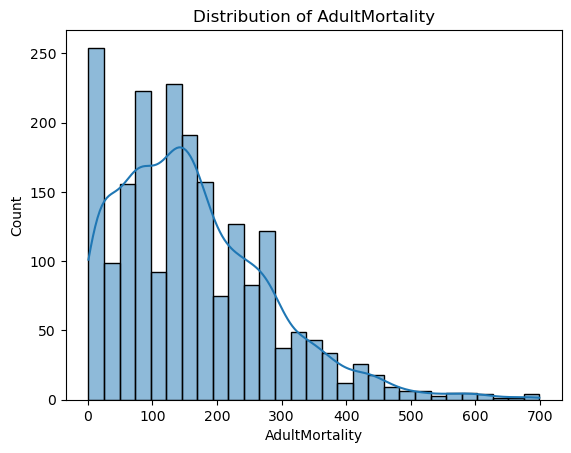

In [9]:
sns.histplot(df['AdultMortality'], kde=True)
plt.title('Distribution of AdultMortality')
plt.show()

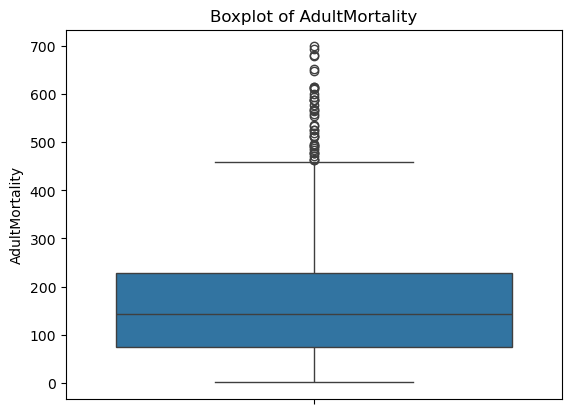

In [11]:
sns.boxplot(df['AdultMortality'])
plt.title('Boxplot of AdultMortality')
plt.show()

In [13]:
print(df['AdultMortality'].skew())

1.0558153940650186


In [15]:
# Fill the missing value in AdultMortality with the mean of AdultMortality-Male and AdultMortality-Female
df.loc[df['AdultMortality'].isnull(), 'AdultMortality'] = df.loc[df['AdultMortality'].isnull(), ['AdultMortality-Male', 'AdultMortality-Female']].mean(axis=1)

In [17]:
# Check for null values
print(df.isnull().sum())

ID                               0
TARGET_LifeExpectancy            0
Country                          0
Year                             0
Status                           0
AdultMortality                   0
AdultMortality-Male              0
AdultMortality-Female            0
SLS                              0
Alcohol                          4
PercentageExpenditure            9
Measles                          1
BMI                              8
Under5LS                         1
Polio                            1
TotalExpenditure                10
Diphtheria                       0
HIV-AIDS                         3
GDP                              9
Population                       8
Thinness1-19years                1
Thinness5-9years                 1
IncomeCompositionOfResources     5
Schooling                        7
dtype: int64


In [19]:
correlation_matrix = df.corr()

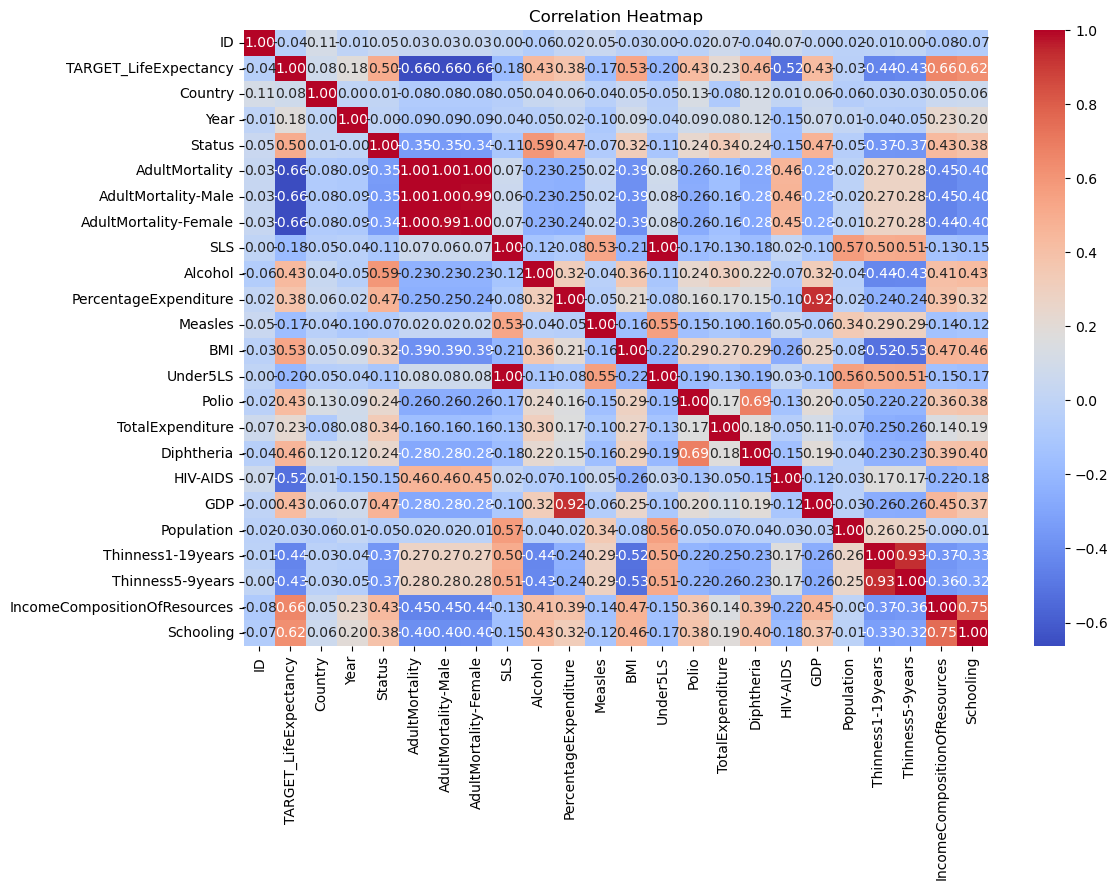

In [21]:
plt.figure(figsize=(12, 8))  # Adjust the figure size
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()

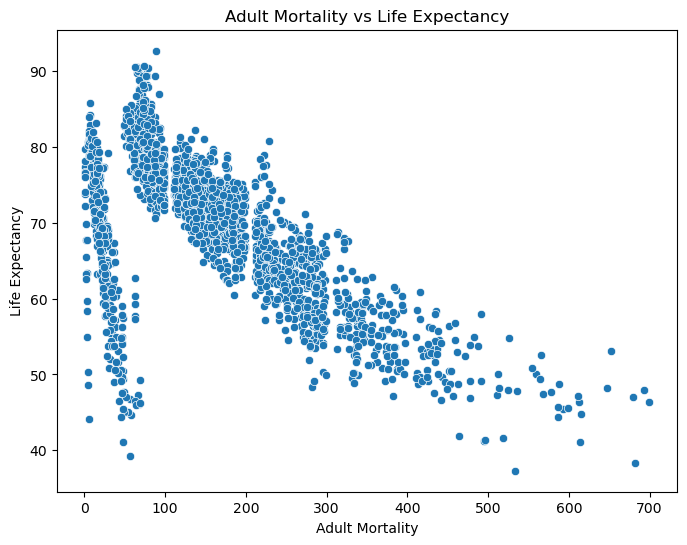

In [22]:
# Scatterplot of AdultMortality vs TARGET_LifeExpectancy
plt.figure(figsize=(8, 6))
sns.scatterplot(x='AdultMortality', y='TARGET_LifeExpectancy', data=df)
plt.title('Adult Mortality vs Life Expectancy')
plt.xlabel('Adult Mortality')
plt.ylabel('Life Expectancy')
plt.show()

In [23]:
print(df['AdultMortality'].describe())

count    2071.000000
mean      162.833897
std       118.872170
min         1.000000
25%        74.000000
50%       144.000000
75%       228.000000
max       699.000000
Name: AdultMortality, dtype: float64


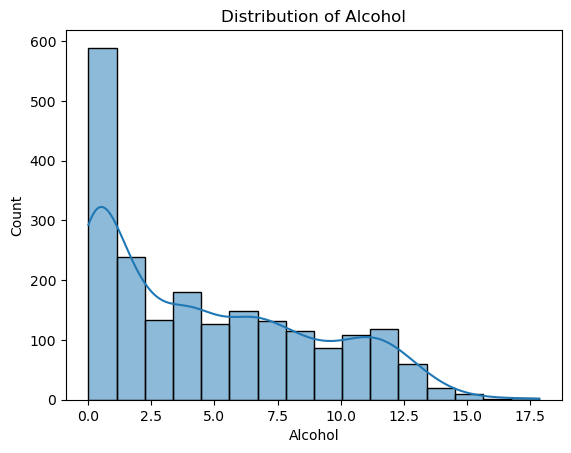

In [24]:
sns.histplot(df['Alcohol'], kde=True)
plt.title('Distribution of Alcohol')
plt.show()

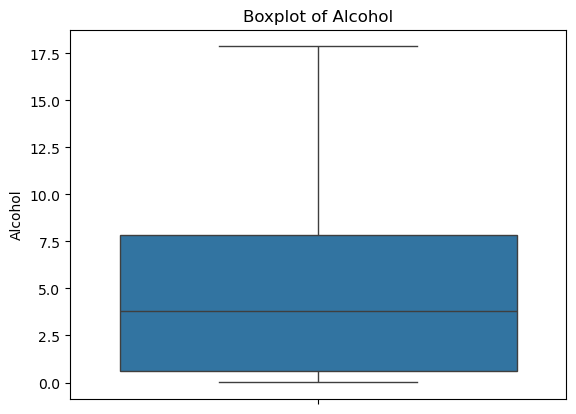

In [25]:
sns.boxplot(df['Alcohol'])
plt.title('Boxplot of Alcohol')
plt.show()

In [26]:
print(f"Skewness of Alcohol column: {df['Alcohol'].skew()}")

Skewness of Alcohol column: 0.5953754953479949


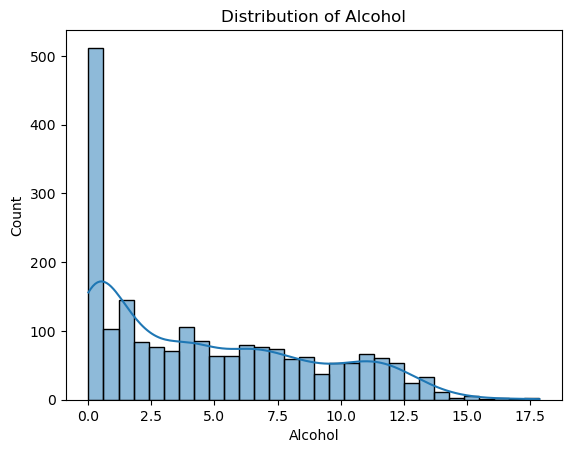

In [27]:
sns.histplot(df['Alcohol'], kde=True, bins=30)
plt.title('Distribution of Alcohol')
plt.show()

In [35]:
# Fill missing Alcohol values with the median
df['Alcohol'] = df['Alcohol'].fillna(df['Alcohol'].median())

In [37]:
print(df['Alcohol'].isnull().sum())  # Should return 0

0


In [39]:
print(df.isnull().sum())

ID                               0
TARGET_LifeExpectancy            0
Country                          0
Year                             0
Status                           0
AdultMortality                   0
AdultMortality-Male              0
AdultMortality-Female            0
SLS                              0
Alcohol                          0
PercentageExpenditure            9
Measles                          1
BMI                              8
Under5LS                         1
Polio                            1
TotalExpenditure                10
Diphtheria                       0
HIV-AIDS                         3
GDP                              9
Population                       8
Thinness1-19years                1
Thinness5-9years                 1
IncomeCompositionOfResources     5
Schooling                        7
dtype: int64


In [41]:
# Print the entire Alcohol column
print(df['PercentageExpenditure'])

0       71.279624
1       73.523582
2       73.219243
3       78.184215
4        7.097109
          ...    
2066     8.369852
2067    65.789974
2068    54.043480
2069          NaN
2070    45.616880
Name: PercentageExpenditure, Length: 2071, dtype: float64


In [43]:
from sklearn.linear_model import LinearRegression

# Step 1: Identify rows where both columns are missing
both_missing = df['PercentageExpenditure'].isnull() & df['GDP'].isnull()

In [44]:
filtered_rows = df[both_missing]
print(filtered_rows)

Empty DataFrame
Columns: [ID, TARGET_LifeExpectancy, Country, Year, Status, AdultMortality, AdultMortality-Male, AdultMortality-Female, SLS, Alcohol, PercentageExpenditure, Measles, BMI, Under5LS, Polio, TotalExpenditure, Diphtheria, HIV-AIDS, GDP, Population, Thinness1-19years, Thinness5-9years, IncomeCompositionOfResources, Schooling]
Index: []

[0 rows x 24 columns]


In [47]:
from sklearn.linear_model import LinearRegression

# Prepare data for training
train_data = df.dropna(subset=['GDP', 'PercentageExpenditure'])
X_gdp = train_data[['PercentageExpenditure']]
y_gdp = train_data['GDP']

model_gdp = LinearRegression()
model_gdp.fit(X_gdp, y_gdp)

# Predict and fill missing GDP values
missing_gdp = df[df['GDP'].isnull()]
df.loc[df['GDP'].isnull(), 'GDP'] = model_gdp.predict(missing_gdp[['PercentageExpenditure']])

In [49]:
# Prepare data for training
X_pe = train_data[['GDP']]
y_pe = train_data['PercentageExpenditure']

model_pe = LinearRegression()
model_pe.fit(X_pe, y_pe)

# Predict and fill missing PercentageExpenditure values
missing_pe = df[df['PercentageExpenditure'].isnull()]
df.loc[df['PercentageExpenditure'].isnull(), 'PercentageExpenditure'] = model_pe.predict(missing_pe[['GDP']])

In [51]:
print(df[['GDP', 'PercentageExpenditure']].isnull().sum())

GDP                      0
PercentageExpenditure    0
dtype: int64


In [53]:
print(df[['GDP', 'PercentageExpenditure']].corr())

                            GDP  PercentageExpenditure
GDP                    1.000000               0.924634
PercentageExpenditure  0.924634               1.000000


In [55]:
print(df.isnull().sum())

ID                               0
TARGET_LifeExpectancy            0
Country                          0
Year                             0
Status                           0
AdultMortality                   0
AdultMortality-Male              0
AdultMortality-Female            0
SLS                              0
Alcohol                          0
PercentageExpenditure            0
Measles                          1
BMI                              8
Under5LS                         1
Polio                            1
TotalExpenditure                10
Diphtheria                       0
HIV-AIDS                         3
GDP                              0
Population                       8
Thinness1-19years                1
Thinness5-9years                 1
IncomeCompositionOfResources     5
Schooling                        7
dtype: int64


In [57]:
print(df['Measles'])

0        1154.0
1         492.0
2         430.0
3        2787.0
4        3013.0
         ...   
2066       35.0
2067      881.0
2068    25036.0
2069    16997.0
2070    30930.0
Name: Measles, Length: 2071, dtype: float64


In [59]:
print(df['Under5LS'])

0       83.0
1       86.0
2       89.0
3       93.0
4       97.0
        ... 
2066    59.0
2067    62.0
2068    66.0
2069    70.0
2070    72.0
Name: Under5LS, Length: 2071, dtype: float64


In [61]:
print(df[['Measles', 'Under5LS']].isnull().sum())

Measles     1
Under5LS    1
dtype: int64


In [63]:
print(df[['Measles', 'Under5LS', 'SLS']].isnull().sum())

Measles     1
Under5LS    1
SLS         0
dtype: int64


In [65]:
from sklearn.linear_model import LinearRegression

# Step 1: Identify rows where both columns are missing
both_missing = df['Measles'].isnull() & df['Under5LS'].isnull()

In [67]:
filtered_rows = df[both_missing]
print(filtered_rows)

Empty DataFrame
Columns: [ID, TARGET_LifeExpectancy, Country, Year, Status, AdultMortality, AdultMortality-Male, AdultMortality-Female, SLS, Alcohol, PercentageExpenditure, Measles, BMI, Under5LS, Polio, TotalExpenditure, Diphtheria, HIV-AIDS, GDP, Population, Thinness1-19years, Thinness5-9years, IncomeCompositionOfResources, Schooling]
Index: []

[0 rows x 24 columns]


In [69]:
# Impute missing value in Under5LS using SLS
df.loc[df['Under5LS'].isnull(), 'Under5LS'] = df.loc[df['Under5LS'].isnull(), 'SLS']

In [71]:
from sklearn.linear_model import LinearRegression

# Prepare training data (exclude rows where Measles is missing)
train_data = df.dropna(subset=['Measles', 'Under5LS', 'SLS'])
X = train_data[['Under5LS', 'SLS']]  # Predictors
y = train_data['Measles']  # Target

# Train regression model
model = LinearRegression()
model.fit(X, y)

# Predict the missing Measles value
missing_measles = df[df['Measles'].isnull()]
df.loc[df['Measles'].isnull(), 'Measles'] = model.predict(missing_measles[['Under5LS', 'SLS']])

In [73]:
print(df[['Measles', 'Under5LS']].isnull().sum())

Measles     0
Under5LS    0
dtype: int64


In [75]:
print(df[['Measles', 'Under5LS', 'SLS']].corr())

           Measles  Under5LS       SLS
Measles   1.000000  0.551714  0.531298
Under5LS  0.551714  1.000000  0.996906
SLS       0.531298  0.996906  1.000000


In [77]:
print(df.isnull().sum())

ID                               0
TARGET_LifeExpectancy            0
Country                          0
Year                             0
Status                           0
AdultMortality                   0
AdultMortality-Male              0
AdultMortality-Female            0
SLS                              0
Alcohol                          0
PercentageExpenditure            0
Measles                          0
BMI                              8
Under5LS                         0
Polio                            1
TotalExpenditure                10
Diphtheria                       0
HIV-AIDS                         3
GDP                              0
Population                       8
Thinness1-19years                1
Thinness5-9years                 1
IncomeCompositionOfResources     5
Schooling                        7
dtype: int64


In [79]:
print(df['Polio'])

0        6.0
1       58.0
2       62.0
3       67.0
4       68.0
        ... 
2066    84.0
2067    85.0
2068    85.0
2069    86.0
2070    85.0
Name: Polio, Length: 2071, dtype: float64


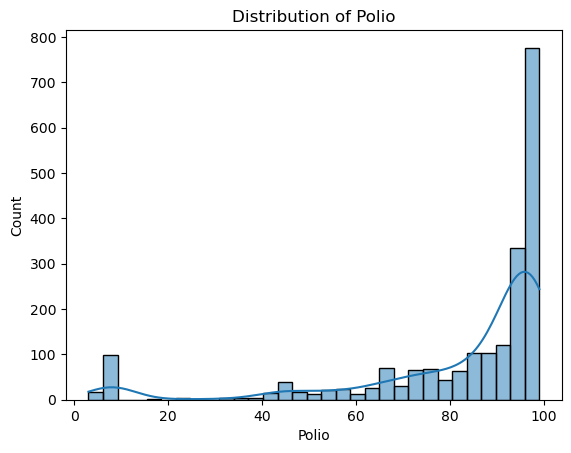

In [81]:
sns.histplot(df['Polio'], kde=True)
plt.title('Distribution of Polio')
plt.show()

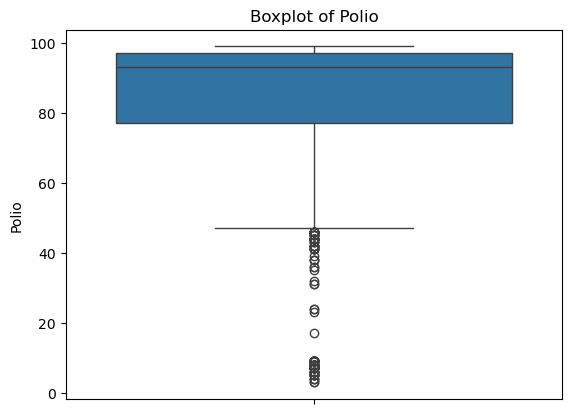

In [83]:
sns.boxplot(df['Polio'])
plt.title('Boxplot of Polio')
plt.show()

In [85]:
print(f"Skewness of Polio column: {df['Polio'].skew()}")

Skewness of Polio column: -2.0686825246656544


In [87]:
print(df[['Polio', 'Diphtheria', 'TARGET_LifeExpectancy']].corr())

                          Polio  Diphtheria  TARGET_LifeExpectancy
Polio                  1.000000    0.688054               0.425999
Diphtheria             0.688054    1.000000               0.457555
TARGET_LifeExpectancy  0.425999    0.457555               1.000000


In [89]:
from sklearn.linear_model import LinearRegression

# Prepare training data
train_data = df.dropna(subset=['Polio', 'Diphtheria'])
X = train_data[['Diphtheria']]  # Predictor
y = train_data['Polio']         # Target

# Train regression model
model = LinearRegression()
model.fit(X, y)

# Predict the missing Polio value
missing_polio = df[df['Polio'].isnull()]
df.loc[df['Polio'].isnull(), 'Polio'] = model.predict(missing_polio[['Diphtheria']])

In [91]:
print(df['Polio'].isnull().sum())  # Should return 0

0


In [93]:
print(df[['Polio', 'Diphtheria', 'TARGET_LifeExpectancy']].corr())

                          Polio  Diphtheria  TARGET_LifeExpectancy
Polio                  1.000000    0.688078               0.426014
Diphtheria             0.688078    1.000000               0.457555
TARGET_LifeExpectancy  0.426014    0.457555               1.000000


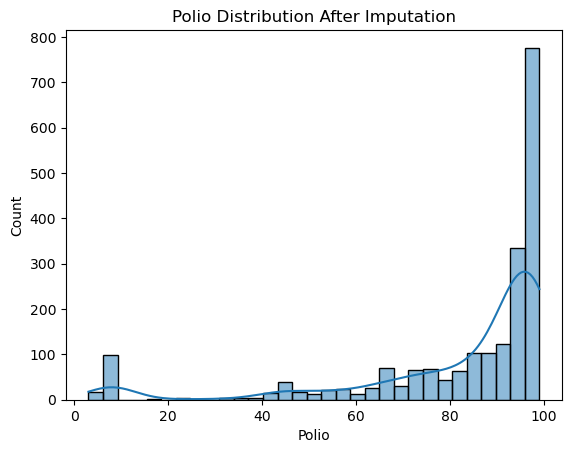

In [95]:
import seaborn as sns
sns.histplot(df['Polio'], kde=True)
plt.title("Polio Distribution After Imputation")
plt.show()

In [97]:
print(df.isnull().sum())

ID                               0
TARGET_LifeExpectancy            0
Country                          0
Year                             0
Status                           0
AdultMortality                   0
AdultMortality-Male              0
AdultMortality-Female            0
SLS                              0
Alcohol                          0
PercentageExpenditure            0
Measles                          0
BMI                              8
Under5LS                         0
Polio                            0
TotalExpenditure                10
Diphtheria                       0
HIV-AIDS                         3
GDP                              0
Population                       8
Thinness1-19years                1
Thinness5-9years                 1
IncomeCompositionOfResources     5
Schooling                        7
dtype: int64


In [99]:
print(df['TotalExpenditure'])

0       8.16
1       8.18
2       8.13
3       8.52
4       7.87
        ... 
2066    7.33
2067    8.18
2068    6.93
2069    6.56
2070    7.16
Name: TotalExpenditure, Length: 2071, dtype: float64


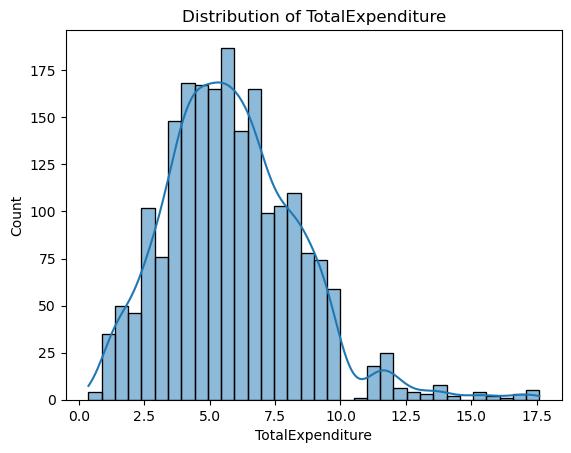

In [101]:
sns.histplot(df['TotalExpenditure'], kde=True)
plt.title('Distribution of TotalExpenditure')
plt.show()

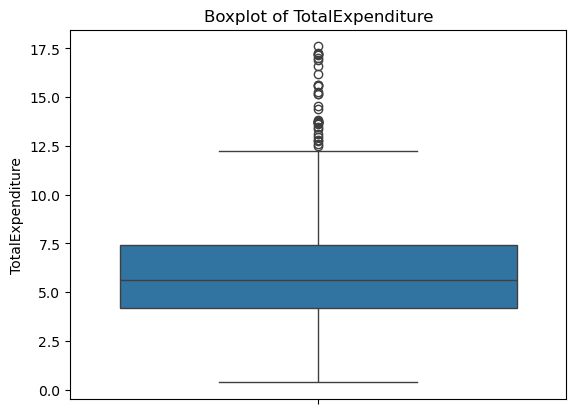

In [103]:
sns.boxplot(df['TotalExpenditure'])
plt.title('Boxplot of TotalExpenditure')
plt.show()

In [105]:
# Calculate correlation of one column (e.g., 'TotalExpenditure') with all other columns
correlations = df.corr()['TotalExpenditure']

# Print the correlation scores
print(correlations)

ID                              0.073884
TARGET_LifeExpectancy           0.226311
Country                        -0.082240
Year                            0.080334
Status                          0.336828
AdultMortality                 -0.157074
AdultMortality-Male            -0.156967
AdultMortality-Female          -0.156519
SLS                            -0.125954
Alcohol                         0.300740
PercentageExpenditure           0.165782
Measles                        -0.100251
BMI                             0.265620
Under5LS                       -0.127574
Polio                           0.166076
TotalExpenditure                1.000000
Diphtheria                      0.177198
HIV-AIDS                       -0.052510
GDP                             0.109157
Population                     -0.071154
Thinness1-19years              -0.249122
Thinness5-9years               -0.264142
IncomeCompositionOfResources    0.142942
Schooling                       0.185260
Name: TotalExpen

In [107]:
print(df.isnull().sum())

ID                               0
TARGET_LifeExpectancy            0
Country                          0
Year                             0
Status                           0
AdultMortality                   0
AdultMortality-Male              0
AdultMortality-Female            0
SLS                              0
Alcohol                          0
PercentageExpenditure            0
Measles                          0
BMI                              8
Under5LS                         0
Polio                            0
TotalExpenditure                10
Diphtheria                       0
HIV-AIDS                         3
GDP                              0
Population                       8
Thinness1-19years                1
Thinness5-9years                 1
IncomeCompositionOfResources     5
Schooling                        7
dtype: int64


In [109]:
from sklearn.linear_model import LinearRegression

# Step 1: Identify rows where both columns are missing
both_missing = df['Thinness1-19years'].isnull() & df['Thinness5-9years'].isnull()

In [111]:
filtered_rows = df[both_missing]
print(filtered_rows)

Empty DataFrame
Columns: [ID, TARGET_LifeExpectancy, Country, Year, Status, AdultMortality, AdultMortality-Male, AdultMortality-Female, SLS, Alcohol, PercentageExpenditure, Measles, BMI, Under5LS, Polio, TotalExpenditure, Diphtheria, HIV-AIDS, GDP, Population, Thinness1-19years, Thinness5-9years, IncomeCompositionOfResources, Schooling]
Index: []

[0 rows x 24 columns]


In [113]:
print(df[['Thinness1-19years', 'Thinness5-9years']].corr())

                   Thinness1-19years  Thinness5-9years
Thinness1-19years           1.000000          0.930454
Thinness5-9years            0.930454          1.000000


In [115]:
from sklearn.linear_model import LinearRegression

# Step 1: Impute Thinness1-19years using Thinness5-9years
train_data = df.dropna(subset=['Thinness1-19years', 'Thinness5-9years'])
X_thinness5 = train_data[['Thinness5-9years']]  # Predictor
y_thinness1 = train_data['Thinness1-19years']   # Target

# Train the regression model
model1 = LinearRegression()
model1.fit(X_thinness5, y_thinness1)

# Predict missing Thinness1-19years
missing_thinness1 = df[df['Thinness1-19years'].isnull()]
df.loc[df['Thinness1-19years'].isnull(), 'Thinness1-19years'] = model1.predict(missing_thinness1[['Thinness5-9years']])

# Step 2: Impute Thinness5-9years using Thinness1-19years
X_thinness1 = train_data[['Thinness1-19years']]  # Predictor
y_thinness5 = train_data['Thinness5-9years']     # Target

model2 = LinearRegression()
model2.fit(X_thinness1, y_thinness5)

# Predict missing Thinness5-9years
missing_thinness5 = df[df['Thinness5-9years'].isnull()]
df.loc[df['Thinness5-9years'].isnull(), 'Thinness5-9years'] = model2.predict(missing_thinness5[['Thinness1-19years']])

In [117]:
print(df[['Thinness1-19years', 'Thinness5-9years']].isnull().sum())  # Should return 0 for both columns

Thinness1-19years    0
Thinness5-9years     0
dtype: int64


In [119]:
print(df[['Thinness1-19years', 'Thinness5-9years']].corr())

                   Thinness1-19years  Thinness5-9years
Thinness1-19years           1.000000          0.930486
Thinness5-9years            0.930486          1.000000


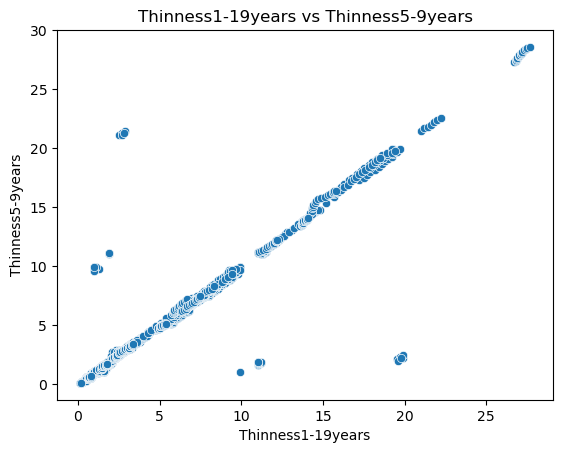

In [121]:
import seaborn as sns
sns.scatterplot(x='Thinness1-19years', y='Thinness5-9years', data=df)
plt.title('Thinness1-19years vs Thinness5-9years')
plt.show()

In [123]:
print(df.isnull().sum())

ID                               0
TARGET_LifeExpectancy            0
Country                          0
Year                             0
Status                           0
AdultMortality                   0
AdultMortality-Male              0
AdultMortality-Female            0
SLS                              0
Alcohol                          0
PercentageExpenditure            0
Measles                          0
BMI                              8
Under5LS                         0
Polio                            0
TotalExpenditure                10
Diphtheria                       0
HIV-AIDS                         3
GDP                              0
Population                       8
Thinness1-19years                0
Thinness5-9years                 0
IncomeCompositionOfResources     5
Schooling                        7
dtype: int64


In [125]:
from sklearn.linear_model import LinearRegression

# Step 1: Identify rows where both columns are missing
both_missing = df['IncomeCompositionOfResources'].isnull() & df['Schooling'].isnull()

In [127]:
filtered_rows = df[both_missing]
print(filtered_rows)

Empty DataFrame
Columns: [ID, TARGET_LifeExpectancy, Country, Year, Status, AdultMortality, AdultMortality-Male, AdultMortality-Female, SLS, Alcohol, PercentageExpenditure, Measles, BMI, Under5LS, Polio, TotalExpenditure, Diphtheria, HIV-AIDS, GDP, Population, Thinness1-19years, Thinness5-9years, IncomeCompositionOfResources, Schooling]
Index: []

[0 rows x 24 columns]


In [129]:
print(df[['IncomeCompositionOfResources', 'Schooling']].corr())

                              IncomeCompositionOfResources  Schooling
IncomeCompositionOfResources                      1.000000   0.752534
Schooling                                         0.752534   1.000000


In [131]:
# Identify rows where both columns have missing values
both_missing = df['IncomeCompositionOfResources'].isnull() & df['Schooling'].isnull()
filtered_rows = df[both_missing]
print(filtered_rows)

Empty DataFrame
Columns: [ID, TARGET_LifeExpectancy, Country, Year, Status, AdultMortality, AdultMortality-Male, AdultMortality-Female, SLS, Alcohol, PercentageExpenditure, Measles, BMI, Under5LS, Polio, TotalExpenditure, Diphtheria, HIV-AIDS, GDP, Population, Thinness1-19years, Thinness5-9years, IncomeCompositionOfResources, Schooling]
Index: []

[0 rows x 24 columns]


In [133]:
from sklearn.linear_model import LinearRegression

# Step 1: Predict missing values in IncomeCompositionOfResources
train_data = df.dropna(subset=['IncomeCompositionOfResources', 'Schooling'])
X_schooling = train_data[['Schooling']]
y_income = train_data['IncomeCompositionOfResources']

# Train the regression model
model_income = LinearRegression()
model_income.fit(X_schooling, y_income)

# Predict missing IncomeCompositionOfResources values
missing_income = df[df['IncomeCompositionOfResources'].isnull()]
df.loc[df['IncomeCompositionOfResources'].isnull(), 'IncomeCompositionOfResources'] = model_income.predict(missing_income[['Schooling']])

# Step 2: Predict missing values in Schooling
X_income = train_data[['IncomeCompositionOfResources']]
y_schooling = train_data['Schooling']

model_schooling = LinearRegression()
model_schooling.fit(X_income, y_schooling)

# Predict missing Schooling values
missing_schooling = df[df['Schooling'].isnull()]
df.loc[df['Schooling'].isnull(), 'Schooling'] = model_schooling.predict(missing_schooling[['IncomeCompositionOfResources']])

In [135]:
print(df[['IncomeCompositionOfResources', 'Schooling']].isnull().sum())  # Should return 0 for both columns

IncomeCompositionOfResources    0
Schooling                       0
dtype: int64


In [137]:
print(df[['IncomeCompositionOfResources', 'Schooling']].corr())

                              IncomeCompositionOfResources  Schooling
IncomeCompositionOfResources                       1.00000    0.75343
Schooling                                          0.75343    1.00000


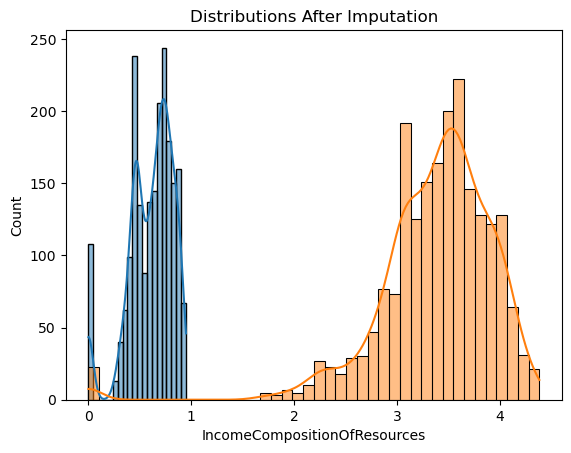

In [139]:
import seaborn as sns
sns.histplot(df['IncomeCompositionOfResources'], kde=True)
sns.histplot(df['Schooling'], kde=True)
plt.title("Distributions After Imputation")
plt.show()

In [141]:
print(df.isnull().sum())

ID                               0
TARGET_LifeExpectancy            0
Country                          0
Year                             0
Status                           0
AdultMortality                   0
AdultMortality-Male              0
AdultMortality-Female            0
SLS                              0
Alcohol                          0
PercentageExpenditure            0
Measles                          0
BMI                              8
Under5LS                         0
Polio                            0
TotalExpenditure                10
Diphtheria                       0
HIV-AIDS                         3
GDP                              0
Population                       8
Thinness1-19years                0
Thinness5-9years                 0
IncomeCompositionOfResources     0
Schooling                        0
dtype: int64


In [143]:
print(df[['HIV-AIDS', 'TARGET_LifeExpectancy', 'AdultMortality', 'AdultMortality-Male', 'AdultMortality-Female']].corr())

                       HIV-AIDS  TARGET_LifeExpectancy  AdultMortality  \
HIV-AIDS               1.000000              -0.521960        0.458570   
TARGET_LifeExpectancy -0.521960               1.000000       -0.663425   
AdultMortality         0.458570              -0.663425        1.000000   
AdultMortality-Male    0.461243              -0.662934        0.997920   
AdultMortality-Female  0.453956              -0.661136        0.997898   

                       AdultMortality-Male  AdultMortality-Female  
HIV-AIDS                          0.461243               0.453956  
TARGET_LifeExpectancy            -0.662934              -0.661136  
AdultMortality                    0.997920               0.997898  
AdultMortality-Male               1.000000               0.991644  
AdultMortality-Female             0.991644               1.000000  


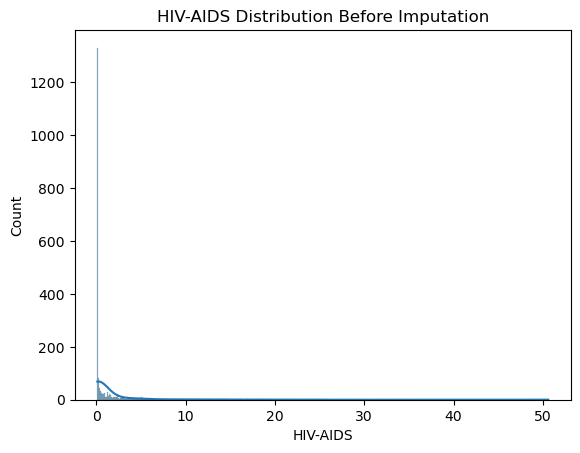

In [145]:
import seaborn as sns
sns.histplot(df['HIV-AIDS'], kde=True)
plt.title("HIV-AIDS Distribution Before Imputation")
plt.show()

In [147]:
from sklearn.linear_model import LinearRegression

# Prepare training data: Exclude rows where HIV-AIDS is missing
train_data = df.dropna(subset=['HIV-AIDS', 'AdultMortality', 'TARGET_LifeExpectancy'])
X = train_data[['AdultMortality', 'AdultMortality-Male', 'AdultMortality-Female', 'TARGET_LifeExpectancy']]  # Predictors
y = train_data['HIV-AIDS']  # Target

# Train the regression model
model = LinearRegression()
model.fit(X, y)

# Predict missing HIV-AIDS values
missing_hiv = df[df['HIV-AIDS'].isnull()]
df.loc[df['HIV-AIDS'].isnull(), 'HIV-AIDS'] = model.predict(missing_hiv[['AdultMortality', 
                                                                        'AdultMortality-Male', 
                                                                        'AdultMortality-Female', 
                                                                        'TARGET_LifeExpectancy']])

In [149]:
print(df['HIV-AIDS'].isnull().sum())  # Should return 0

0


In [151]:
print(df[['HIV-AIDS', 'AdultMortality', 'TARGET_LifeExpectancy']].corr())

                       HIV-AIDS  AdultMortality  TARGET_LifeExpectancy
HIV-AIDS               1.000000        0.459014              -0.522312
AdultMortality         0.459014        1.000000              -0.663425
TARGET_LifeExpectancy -0.522312       -0.663425               1.000000


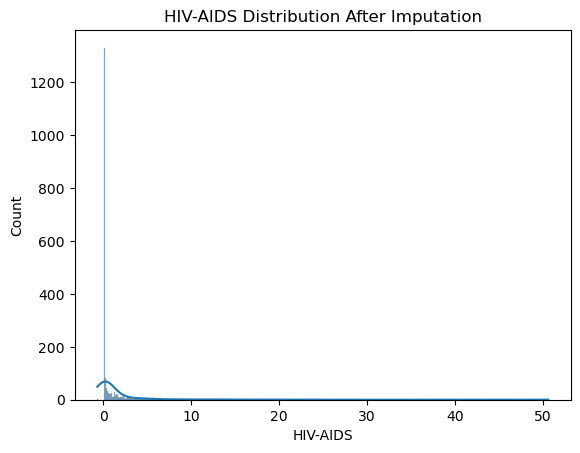

In [153]:
import seaborn as sns
sns.histplot(df['HIV-AIDS'], kde=True)
plt.title("HIV-AIDS Distribution After Imputation")
plt.show()

In [154]:
print(df.isnull().sum())

ID                               0
TARGET_LifeExpectancy            0
Country                          0
Year                             0
Status                           0
AdultMortality                   0
AdultMortality-Male              0
AdultMortality-Female            0
SLS                              0
Alcohol                          0
PercentageExpenditure            0
Measles                          0
BMI                              8
Under5LS                         0
Polio                            0
TotalExpenditure                10
Diphtheria                       0
HIV-AIDS                         0
GDP                              0
Population                       8
Thinness1-19years                0
Thinness5-9years                 0
IncomeCompositionOfResources     0
Schooling                        0
dtype: int64


In [157]:
print(df[['Population', 'SLS', 'Under5LS']].corr())

            Population       SLS  Under5LS
Population    1.000000  0.570785  0.556169
SLS           0.570785  1.000000  0.996906
Under5LS      0.556169  0.996906  1.000000


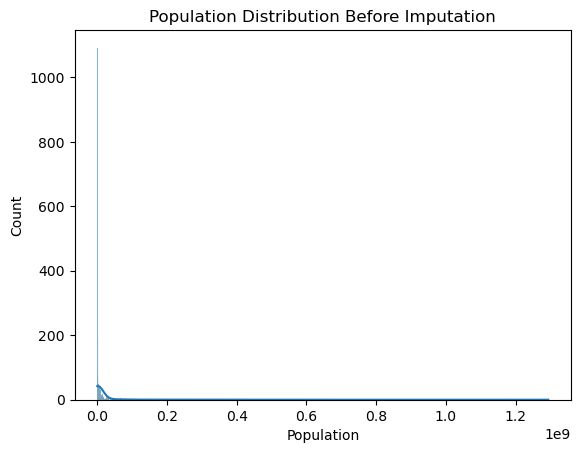

In [159]:
import seaborn as sns
sns.histplot(df['Population'], kde=True)
plt.title("Population Distribution Before Imputation")
plt.show()

In [161]:
from sklearn.linear_model import LinearRegression

# Prepare training data: Exclude rows where Population is missing
train_data = df.dropna(subset=['Population', 'SLS', 'Under5LS'])
X = train_data[['SLS', 'Under5LS']]  # Predictors
y = train_data['Population']         # Target

# Train the regression model
model = LinearRegression()
model.fit(X, y)

# Predict missing Population values
missing_population = df[df['Population'].isnull()]
df.loc[df['Population'].isnull(), 'Population'] = model.predict(missing_population[['SLS', 'Under5LS']])

In [163]:
print(df['Population'].isnull().sum())  # Should return 0

0


In [165]:
print(df[['Population', 'SLS', 'Under5LS']].corr())

            Population       SLS  Under5LS
Population    1.000000  0.570763  0.556115
SLS           0.570763  1.000000  0.996906
Under5LS      0.556115  0.996906  1.000000


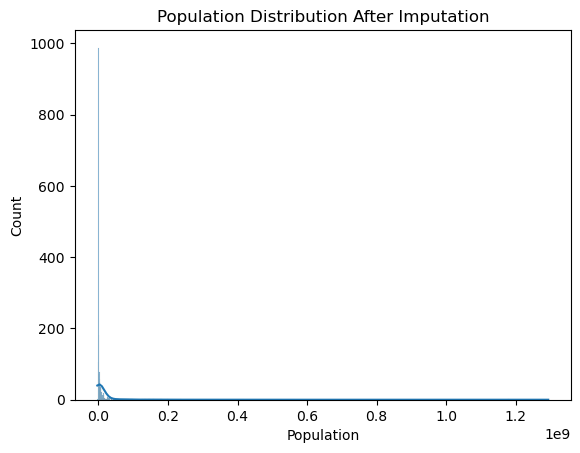

In [167]:
import seaborn as sns
sns.histplot(df['Population'], kde=True)
plt.title("Population Distribution After Imputation")
plt.show()

In [169]:
print(df.isnull().sum())

ID                               0
TARGET_LifeExpectancy            0
Country                          0
Year                             0
Status                           0
AdultMortality                   0
AdultMortality-Male              0
AdultMortality-Female            0
SLS                              0
Alcohol                          0
PercentageExpenditure            0
Measles                          0
BMI                              8
Under5LS                         0
Polio                            0
TotalExpenditure                10
Diphtheria                       0
HIV-AIDS                         0
GDP                              0
Population                       0
Thinness1-19years                0
Thinness5-9years                 0
IncomeCompositionOfResources     0
Schooling                        0
dtype: int64


In [171]:
# Calculate correlation of one column (e.g., 'BMI') with all other columns
correlations = df.corr()['BMI']

# Print the correlation scores
print(correlations)

ID                             -0.026087
TARGET_LifeExpectancy           0.531797
Country                         0.049447
Year                            0.094800
Status                          0.317009
AdultMortality                 -0.393278
AdultMortality-Male            -0.393420
AdultMortality-Female          -0.391486
SLS                            -0.213710
Alcohol                         0.359202
PercentageExpenditure           0.213069
Measles                        -0.159027
BMI                             1.000000
Under5LS                       -0.223563
Polio                           0.290715
TotalExpenditure                0.265620
Diphtheria                      0.293891
HIV-AIDS                       -0.255400
GDP                             0.252035
Population                     -0.075106
Thinness1-19years              -0.516421
Thinness5-9years               -0.526500
IncomeCompositionOfResources    0.470890
Schooling                       0.460492
Name: BMI, dtype

In [173]:
# Check overlap with missing predictors
missing_overlap = df['IncomeCompositionOfResources'].isnull() & df['Schooling'].isnull() & df['TARGET_LifeExpectancy'].notnull()
print(missing_overlap.sum())  # Count rows where predictors are missing

0


In [175]:
from sklearn.linear_model import LinearRegression

# Prepare training data: Exclude rows where BMI is missing
train_data = df.dropna(subset=['BMI', 'TARGET_LifeExpectancy', 'IncomeCompositionOfResources', 'Schooling'])
X = train_data[['TARGET_LifeExpectancy', 'IncomeCompositionOfResources', 'Schooling']]  # Predictors
y = train_data['BMI']  # Target

# Train the regression model
model = LinearRegression()
model.fit(X, y)

# Predict missing BMI values
missing_bmi = df[df['BMI'].isnull()]
df.loc[df['BMI'].isnull(), 'BMI'] = model.predict(missing_bmi[['TARGET_LifeExpectancy', 'IncomeCompositionOfResources', 'Schooling']])

In [177]:
print(df['BMI'].isnull().sum())  # Should return 0

0


In [179]:
print(df[['BMI', 'TARGET_LifeExpectancy', 'IncomeCompositionOfResources', 'Schooling']].corr())

                                   BMI  TARGET_LifeExpectancy  \
BMI                           1.000000               0.532606   
TARGET_LifeExpectancy         0.532606               1.000000   
IncomeCompositionOfResources  0.471700               0.660131   
Schooling                     0.461215               0.624253   

                              IncomeCompositionOfResources  Schooling  
BMI                                               0.471700   0.461215  
TARGET_LifeExpectancy                             0.660131   0.624253  
IncomeCompositionOfResources                      1.000000   0.753430  
Schooling                                         0.753430   1.000000  


In [181]:
print(df.isnull().sum())

ID                               0
TARGET_LifeExpectancy            0
Country                          0
Year                             0
Status                           0
AdultMortality                   0
AdultMortality-Male              0
AdultMortality-Female            0
SLS                              0
Alcohol                          0
PercentageExpenditure            0
Measles                          0
BMI                              0
Under5LS                         0
Polio                            0
TotalExpenditure                10
Diphtheria                       0
HIV-AIDS                         0
GDP                              0
Population                       0
Thinness1-19years                0
Thinness5-9years                 0
IncomeCompositionOfResources     0
Schooling                        0
dtype: int64


In [183]:
# Calculate correlation of one column (e.g., 'TotalExpenditure') with all other columns
correlations = df.corr()['TotalExpenditure']

# Print the correlation scores
print(correlations)

ID                              0.073884
TARGET_LifeExpectancy           0.226311
Country                        -0.082240
Year                            0.080334
Status                          0.336828
AdultMortality                 -0.157074
AdultMortality-Male            -0.156967
AdultMortality-Female          -0.156519
SLS                            -0.125954
Alcohol                         0.300740
PercentageExpenditure           0.165782
Measles                        -0.100251
BMI                             0.265528
Under5LS                       -0.127574
Polio                           0.166076
TotalExpenditure                1.000000
Diphtheria                      0.177198
HIV-AIDS                       -0.052578
GDP                             0.109157
Population                     -0.070984
Thinness1-19years              -0.249523
Thinness5-9years               -0.264188
IncomeCompositionOfResources    0.141789
Schooling                       0.185833
Name: TotalExpen

In [185]:
print(df[['TotalExpenditure', 'Status', 'Alcohol', 'BMI']].corr())

                  TotalExpenditure    Status   Alcohol       BMI
TotalExpenditure          1.000000  0.336828  0.300740  0.265528
Status                    0.336828  1.000000  0.593349  0.317072
Alcohol                   0.300740  0.593349  1.000000  0.359212
BMI                       0.265528  0.317072  0.359212  1.000000


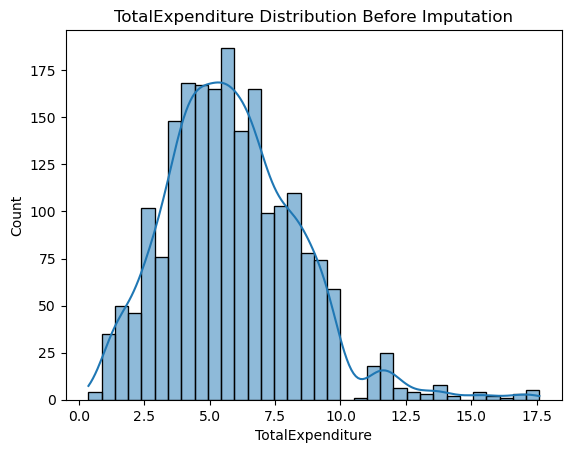

In [187]:
import seaborn as sns
sns.histplot(df['TotalExpenditure'], kde=True)
plt.title("TotalExpenditure Distribution Before Imputation")
plt.show()

In [189]:
from sklearn.linear_model import LinearRegression

# Prepare training data: Exclude rows where TotalExpenditure is missing
train_data = df.dropna(subset=['TotalExpenditure'])
X = train_data[['Status', 'Alcohol', 'BMI']]  # Predictors
y = train_data['TotalExpenditure']           # Target

# Train the regression model
model = LinearRegression()
model.fit(X, y)

# Predict missing TotalExpenditure values
missing_expenditure = df[df['TotalExpenditure'].isnull()]
df.loc[df['TotalExpenditure'].isnull(), 'TotalExpenditure'] = model.predict(missing_expenditure[['Status', 'Alcohol', 'BMI']])

In [191]:
print(df['TotalExpenditure'].isnull().sum())  # Should return 0

0


In [193]:
print(df[['TotalExpenditure', 'Status', 'Alcohol', 'BMI']].corr())

                  TotalExpenditure    Status   Alcohol       BMI
TotalExpenditure          1.000000  0.337751  0.301601  0.266464
Status                    0.337751  1.000000  0.593349  0.317072
Alcohol                   0.301601  0.593349  1.000000  0.359212
BMI                       0.266464  0.317072  0.359212  1.000000


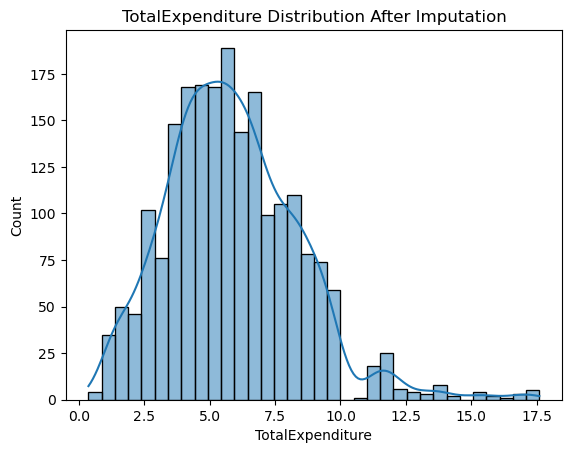

In [195]:
import seaborn as sns
sns.histplot(df['TotalExpenditure'], kde=True)
plt.title("TotalExpenditure Distribution After Imputation")
plt.show()

In [197]:
print(df.isnull().sum())

ID                              0
TARGET_LifeExpectancy           0
Country                         0
Year                            0
Status                          0
AdultMortality                  0
AdultMortality-Male             0
AdultMortality-Female           0
SLS                             0
Alcohol                         0
PercentageExpenditure           0
Measles                         0
BMI                             0
Under5LS                        0
Polio                           0
TotalExpenditure                0
Diphtheria                      0
HIV-AIDS                        0
GDP                             0
Population                      0
Thinness1-19years               0
Thinness5-9years                0
IncomeCompositionOfResources    0
Schooling                       0
dtype: int64


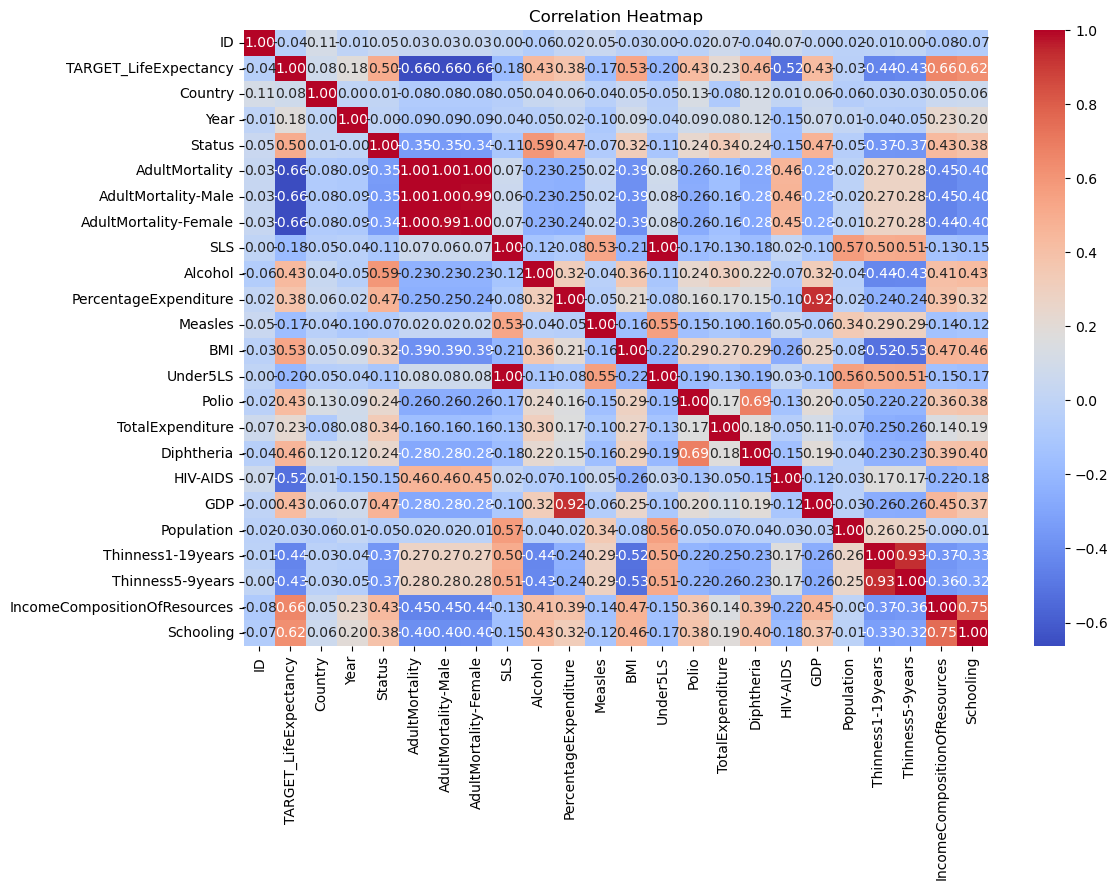

In [199]:
plt.figure(figsize=(12, 8))  # Adjust the figure size
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()

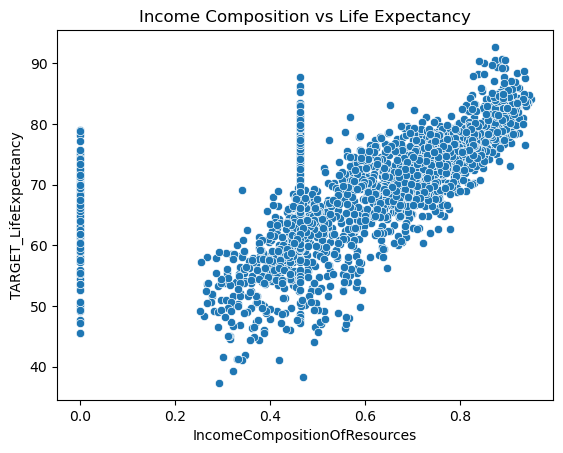

In [201]:
sns.scatterplot(x='IncomeCompositionOfResources', y='TARGET_LifeExpectancy', data=df)
plt.title("Income Composition vs Life Expectancy")
plt.show()

In [203]:
# Calculate correlation of one column (e.g., 'TotalExpenditure') with all other columns
correlations = df.corr()['TARGET_LifeExpectancy']

# Print the correlation scores
print(correlations)

ID                             -0.040947
TARGET_LifeExpectancy           1.000000
Country                         0.080722
Year                            0.181780
Status                          0.504971
AdultMortality                 -0.663425
AdultMortality-Male            -0.662934
AdultMortality-Female          -0.661136
SLS                            -0.179600
Alcohol                         0.432450
PercentageExpenditure           0.378234
Measles                        -0.168519
BMI                             0.532606
Under5LS                       -0.201326
Polio                           0.426014
TotalExpenditure                0.227315
Diphtheria                      0.457555
HIV-AIDS                       -0.522312
GDP                             0.428286
Population                     -0.028869
Thinness1-19years              -0.436399
Thinness5-9years               -0.428569
IncomeCompositionOfResources    0.660131
Schooling                       0.624253
Name: TARGET_Lif

In [205]:
print(df[['IncomeCompositionOfResources', 'Schooling', 'AdultMortality', 'BMI', 'Status', 'HIV-AIDS', 'GDP', 'Diphtheria', 'Polio', 'Thinness1-19years', 'Thinness5-9years']].corr())

                              IncomeCompositionOfResources  Schooling  \
IncomeCompositionOfResources                      1.000000   0.753430   
Schooling                                         0.753430   1.000000   
AdultMortality                                   -0.444332  -0.399488   
BMI                                               0.471700   0.461215   
Status                                            0.433783   0.384956   
HIV-AIDS                                         -0.216895  -0.181801   
GDP                                               0.451128   0.369483   
Diphtheria                                        0.390501   0.398933   
Polio                                             0.361117   0.379182   
Thinness1-19years                                -0.368798  -0.329513   
Thinness5-9years                                 -0.355620  -0.317233   

                              AdultMortality       BMI    Status  HIV-AIDS  \
IncomeCompositionOfResources       -0.444332 

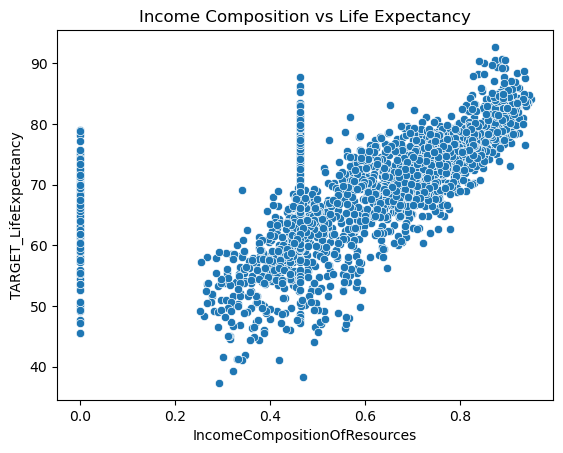

In [207]:
sns.scatterplot(x='IncomeCompositionOfResources', y='TARGET_LifeExpectancy', data=df)
plt.title("Income Composition vs Life Expectancy")
plt.show()

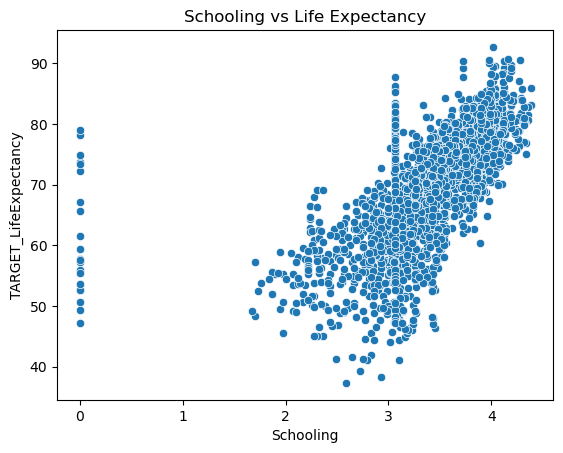

In [209]:
sns.scatterplot(x='Schooling', y='TARGET_LifeExpectancy', data=df)
plt.title("Schooling vs Life Expectancy")
plt.show()

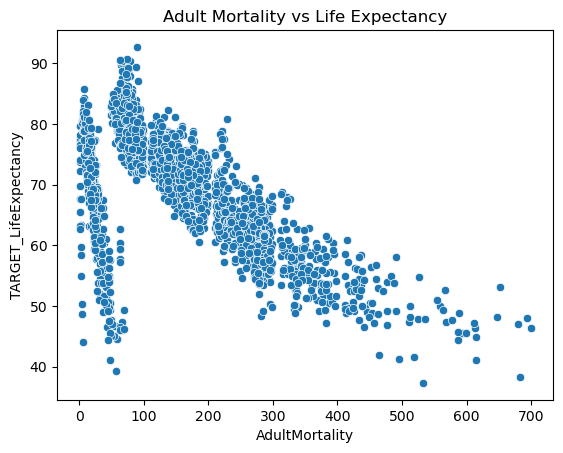

In [211]:
sns.scatterplot(x='AdultMortality', y='TARGET_LifeExpectancy', data=df)
plt.title("Adult Mortality vs Life Expectancy")
plt.show()

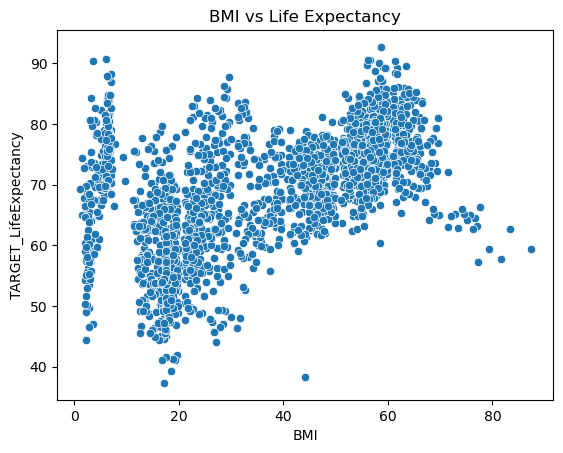

In [213]:
sns.scatterplot(x='BMI', y='TARGET_LifeExpectancy', data=df)
plt.title("BMI vs Life Expectancy")
plt.show()

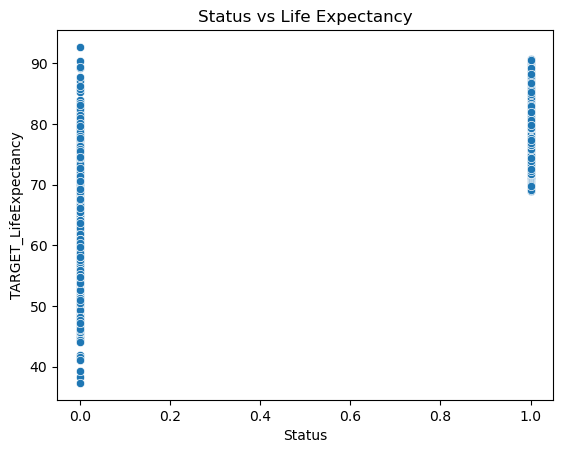

In [215]:
sns.scatterplot(x='Status', y='TARGET_LifeExpectancy', data=df)
plt.title("Status vs Life Expectancy")
plt.show()

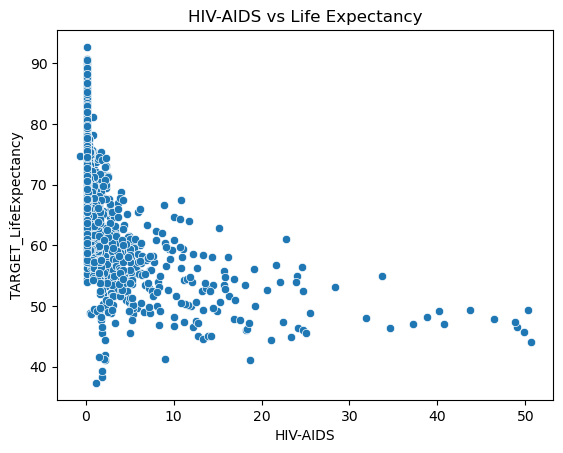

In [217]:
sns.scatterplot(x='HIV-AIDS', y='TARGET_LifeExpectancy', data=df)
plt.title("HIV-AIDS vs Life Expectancy")
plt.show()

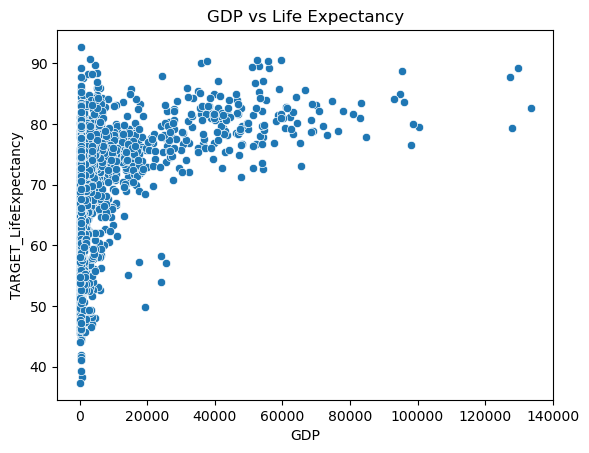

In [219]:
sns.scatterplot(x='GDP', y='TARGET_LifeExpectancy', data=df)
plt.title("GDP vs Life Expectancy")
plt.show()

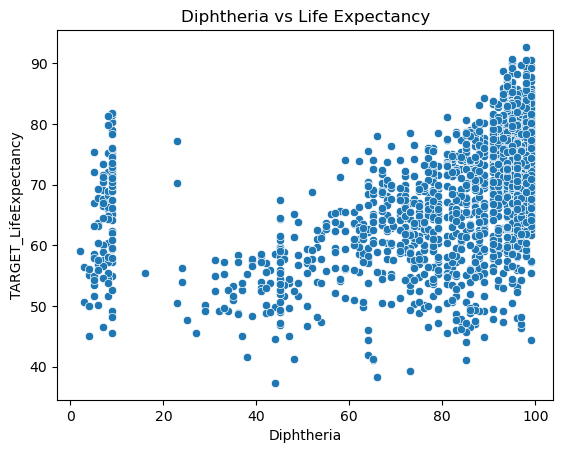

In [221]:
sns.scatterplot(x='Diphtheria', y='TARGET_LifeExpectancy', data=df)
plt.title("Diphtheria vs Life Expectancy")
plt.show()

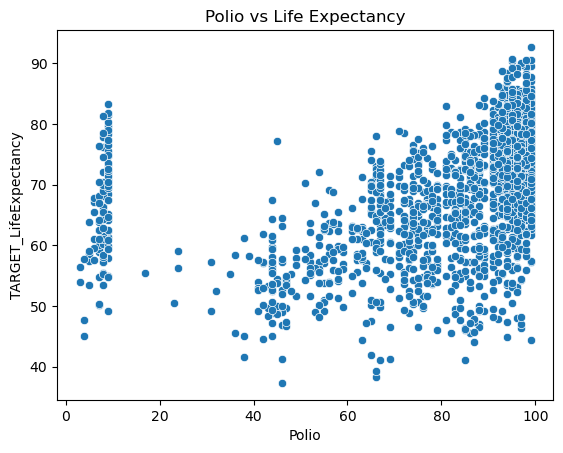

In [223]:
sns.scatterplot(x='Polio', y='TARGET_LifeExpectancy', data=df)
plt.title("Polio vs Life Expectancy")
plt.show()

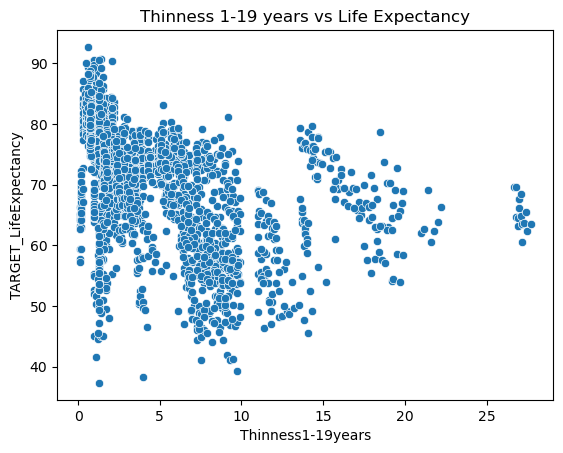

In [225]:
sns.scatterplot(x='Thinness1-19years', y='TARGET_LifeExpectancy', data=df)
plt.title("Thinness 1-19 years vs Life Expectancy")
plt.show()

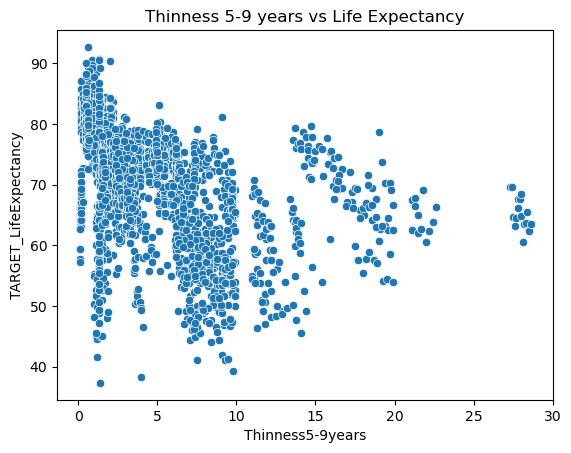

In [227]:
sns.scatterplot(x='Thinness5-9years', y='TARGET_LifeExpectancy', data=df)
plt.title("Thinness 5-9 years vs Life Expectancy")
plt.show()

In [229]:
from sklearn.preprocessing import StandardScaler

In [231]:
scaler = StandardScaler()

In [233]:
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [235]:
scaler = joblib.load('scaler.pkl')

In [237]:
from sklearn.model_selection import train_test_split

# Load your dataset
X = df.drop(columns=['ID', 'TARGET_LifeExpectancy', 'Country', 'Year', 'Status'])  # Predictors
y = df['TARGET_LifeExpectancy']  # Target variable

# Step 1: Split into training (60%) and temporary set (40%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

# Step 2: Split the temporary set into validation (50% of temp) and test (50% of temp)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print the sizes of the splits to confirm proportions
print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

Training set: 1242 samples
Validation set: 414 samples
Test set: 415 samples


In [239]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training set and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test sets using the same scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [241]:
print(X_val_scaled)

[[ 0.13913366  0.18021736  0.09758654 ...  2.60712301 -0.43727529
  -0.05870644]
 [-0.52029618 -0.53681223 -0.50184872 ... -0.65083239  0.39213381
   0.01433865]
 [-0.60376831 -0.62018776 -0.58510361 ... -0.37581018  0.80912954
   0.58906769]
 ...
 [-0.79575421 -0.80361394 -0.78491536 ...  0.49156755 -1.09713667
  -0.41343331]
 [ 0.7317858   0.74717098  0.71367277 ...  0.57618977 -0.27689232
  -0.05870644]
 [ 0.2893835   0.31361821  0.26409633 ... -0.31234352  0.39213381
   0.18112621]]


In [243]:
print(df.isnull().sum())

ID                              0
TARGET_LifeExpectancy           0
Country                         0
Year                            0
Status                          0
AdultMortality                  0
AdultMortality-Male             0
AdultMortality-Female           0
SLS                             0
Alcohol                         0
PercentageExpenditure           0
Measles                         0
BMI                             0
Under5LS                        0
Polio                           0
TotalExpenditure                0
Diphtheria                      0
HIV-AIDS                        0
GDP                             0
Population                      0
Thinness1-19years               0
Thinness5-9years                0
IncomeCompositionOfResources    0
Schooling                       0
dtype: int64


In [245]:
from sklearn.linear_model import LinearRegression

# Initialize and train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions on the validation set
y_val_pred = model.predict(X_val_scaled)

In [247]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate performance on validation set
mae = mean_absolute_error(y_val, y_val_pred)
rmse = mean_squared_error(y_val, y_val_pred, squared=False)
r2 = r2_score(y_val, y_val_pred)

print(f"Validation MAE: {mae}")
print(f"Validation RMSE: {rmse}")
print(f"Validation R²: {r2}")

Validation MAE: 3.6846296982070434
Validation RMSE: 4.888245847136402
Validation R²: 0.7348514968919129


C:\Users\tanha\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [249]:
joblib.dump(model, 'linear_model.pkl')

['linear_model.pkl']

In [251]:
linear_model = joblib.load('linear_model.pkl')

In [253]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# Define Ridge model
ridge = Ridge()

# Define hyperparameter grid (alpha values to test)
param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}

# Perform grid search
ridge_grid = GridSearchCV(estimator=ridge, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_scaled, y_train)

# Get the best alpha value
print(f"Best Ridge alpha: {ridge_grid.best_params_}")

Best Ridge alpha: {'alpha': 0.1}


In [255]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize Ridge Regression with the best alpha value
ridge = Ridge(alpha=0.1)
ridge.fit(X_train_scaled, y_train)

# Predict on the validation set
y_val_pred_ridge = ridge.predict(X_val_scaled)

# Evaluate Performance
ridge_mae = mean_absolute_error(y_val, y_val_pred_ridge)
ridge_rmse = mean_squared_error(y_val, y_val_pred_ridge, squared=False)
ridge_r2 = r2_score(y_val, y_val_pred_ridge)

print(f"Ridge Regression - Validation Performance:")
print(f"MAE: {ridge_mae}, RMSE: {ridge_rmse}, R²: {ridge_r2}")

Ridge Regression - Validation Performance:
MAE: 3.6860551762671205, RMSE: 4.891208311465018, R²: 0.7345300191977704


C:\Users\tanha\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [257]:
import joblib
joblib.dump(ridge, 'ridge_model.pkl')

['ridge_model.pkl']

In [259]:
ridge = joblib.load('ridge_model.pkl')

In [261]:
param_grid = {'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0]}
ridge_grid = GridSearchCV(estimator=Ridge(), param_grid=param_grid, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

print(f"Best Ridge alpha: {ridge_grid.best_params_}")
print(f"Best R²: {ridge_grid.best_score_}")

Best Ridge alpha: {'alpha': 0.01}
Best R²: 0.7407041488069133


In [263]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Lasso
from scipy.stats import uniform

# Define Lasso model
lasso = Lasso()

# Define hyperparameter distribution (alpha values sampled randomly)
param_dist = {'alpha': uniform(0.01, 10)}  # Random sampling between 0.01 and 10

# Perform randomized search
lasso_random = RandomizedSearchCV(estimator=lasso, param_distributions=param_dist, n_iter=100, cv=5, random_state=42)
lasso_random.fit(X_train_scaled, y_train)

# Get the best alpha value
print(f"Best Lasso alpha: {lasso_random.best_params_}")

Best Lasso alpha: {'alpha': 0.21584494295802448}


In [265]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize Lasso Regression with the best alpha value
lasso = Lasso(alpha=0.21584494295802448)
lasso.fit(X_train_scaled, y_train)

# Predict on the validation set
y_val_pred_lasso = lasso.predict(X_val_scaled)

# Evaluate Performance
lasso_mae = mean_absolute_error(y_val, y_val_pred_lasso)
lasso_rmse = mean_squared_error(y_val, y_val_pred_lasso, squared=False)
lasso_r2 = r2_score(y_val, y_val_pred_lasso)

print(f"Lasso Regression - Validation Performance:")
print(f"MAE: {lasso_mae}, RMSE: {lasso_rmse}, R²: {lasso_r2}")

Lasso Regression - Validation Performance:
MAE: 3.828345639353474, RMSE: 5.112819365580956, R²: 0.7099292093696672


C:\Users\tanha\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [267]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Create a polynomial regression model (degree=2)
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

# Fit the model
poly_model.fit(X_train_scaled, y_train)

# Predict on validation set
y_val_pred_poly = poly_model.predict(X_val_scaled)

# Evaluate Performance
poly_mae = mean_absolute_error(y_val, y_val_pred_poly)
poly_rmse = mean_squared_error(y_val, y_val_pred_poly, squared=False)
poly_r2 = r2_score(y_val, y_val_pred_poly)

print(f"Polynomial MAE: {poly_mae}, RMSE: {poly_rmse}, R²: {poly_r2}")

Polynomial MAE: 3.270541730882774, RMSE: 5.186671472463516, R²: 0.7014888343232072


C:\Users\tanha\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [269]:
# Predict on the test set using Ridge Regression
y_test_pred_ridge = ridge.predict(X_test_scaled)

# Evaluate Ridge Regression on the test set
ridge_test_mae = mean_absolute_error(y_test, y_test_pred_ridge)
ridge_test_rmse = mean_squared_error(y_test, y_test_pred_ridge, squared=False)
ridge_test_r2 = r2_score(y_test, y_test_pred_ridge)

print(f"Ridge Regression - Test Performance:")
print(f"MAE: {ridge_test_mae}, RMSE: {ridge_test_rmse}, R²: {ridge_test_r2}")

Ridge Regression - Test Performance:
MAE: 3.5275008104024024, RMSE: 4.56587333579583, R²: 0.7567500605051518


C:\Users\tanha\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [271]:
# Predict on the test set using Linear Regression
y_test_pred_linear = linear_model.predict(X_test_scaled)  # Replace with your Linear Regression instance

# Evaluate Linear Regression on the test set
linear_test_mae = mean_absolute_error(y_test, y_test_pred_linear)
linear_test_rmse = mean_squared_error(y_test, y_test_pred_linear, squared=False)
linear_test_r2 = r2_score(y_test, y_test_pred_linear)

print(f"Linear Regression - Test Performance:")
print(f"MAE: {linear_test_mae}, RMSE: {linear_test_rmse}, R²: {linear_test_r2}")

Linear Regression - Test Performance:
MAE: 3.5324632778335423, RMSE: 4.570003541946424, R²: 0.7563097825006961


C:\Users\tanha\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [273]:
# Predict on the test set using Linear Regression
y_test_pred_lasso = lasso.predict(X_test_scaled)  # Replace with your Linear Regression instance

# Evaluate Linear Regression on the test set
lasso_test_mae = mean_absolute_error(y_test, y_test_pred_lasso)
lasso_test_rmse = mean_squared_error(y_test, y_test_pred_lasso, squared=False)
lasso_test_r2 = r2_score(y_test, y_test_pred_lasso)

print(f"Lasso Regression - Test Performance:")
print(f"MAE: {lasso_test_mae}, RMSE: {lasso_test_rmse}, R²: {lasso_test_r2}")

Lasso Regression - Test Performance:
MAE: 3.4879185194421387, RMSE: 4.570986501081241, R²: 0.7562049408811464


C:\Users\tanha\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [275]:
# Predict on the test set using Linear Regression
y_test_pred_poly = poly_model.predict(X_test_scaled)  # Replace with your Linear Regression instance

# Evaluate Linear Regression on the test set
poly_test_mae = mean_absolute_error(y_test, y_test_pred_poly)
poly_test_rmse = mean_squared_error(y_test, y_test_pred_poly, squared=False)
poly_test_r2 = r2_score(y_test, y_test_pred_poly)

print(f"Polynomial Regression - Test Performance:")
print(f"MAE: {poly_test_mae}, RMSE: {poly_test_rmse}, R²: {poly_test_r2}")

Polynomial Regression - Test Performance:
MAE: 3.002951281360396, RMSE: 4.4152326510540645, R²: 0.7725362432106585


C:\Users\tanha\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [277]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train_scaled, y_train)

# Predict on validation set
y_val_pred_rf = rf_model.predict(X_val_scaled)

# Evaluate model performance
rf_mae = mean_absolute_error(y_val, y_val_pred_rf)
rf_rmse = mean_squared_error(y_val, y_val_pred_rf, squared=False)
rf_r2 = r2_score(y_val, y_val_pred_rf)

print(f"Random Forest MAE: {rf_mae}, RMSE: {rf_rmse}, R²: {rf_r2}")

Random Forest MAE: 2.1870990338164256, RMSE: 2.898657386606348, R²: 0.906765451590384


C:\Users\tanha\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [279]:
# Predict on test set using the trained Random Forest model
y_test_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate model performance on test data
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)
rf_test_rmse = mean_squared_error(y_test, y_test_pred_rf, squared=False)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)

# Print test set results
print(f"Random Forest - Test Set Performance:")
print(f"MAE: {rf_test_mae}, RMSE: {rf_test_rmse}, R²: {rf_test_r2}")

Random Forest - Test Set Performance:
MAE: 2.178922891566264, RMSE: 2.82594586489644, R²: 0.9068178560944272


C:\Users\tanha\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [283]:
import pandas as pd

# ---------------------------
# 1. Load the Test Dataset
# ---------------------------
test_df = pd.read_csv('test.csv')
print("Test Data Preview (original):")
print(test_df.head())

# ---------------------------
# 2. Prepare the Test Features for Prediction
# ---------------------------
# Suppose during training you dropped these columns:
cols_to_drop = ['Country', 'Status', 'Year', 'ID']  # adjust as needed

# Create a new DataFrame with the same feature selection as in training
if all(col in test_df.columns for col in cols_to_drop):
    X_test = test_df.drop(columns=cols_to_drop)
else:
    X_test = test_df.copy()  # fallback in case some columns are missing

print("Features used for prediction:")
print(X_test.head())

# ---------------------------
# 3. Preprocess the Test Features
# ---------------------------
# Here we assume that `scaler` has been previously fitted on the training data
X_test_scaled = scaler.transform(X_test)

# ---------------------------
# 4. Predict Using the Trained Random Forest Model
# ---------------------------
test_predictions = rf_model.predict(X_test_scaled)

# ---------------------------
# 5. Merge Predictions and Export Results
# ---------------------------

# Round predictions to 1 decimal place
test_predictions_rounded = np.round(test_predictions, 1)

# Now, merge the rounded predictions into the result DataFrame
result_df = test_df.copy()
result_df['TARGET_LifeExpectancy'] = test_predictions_rounded

# Save the full DataFrame to CSV using the required naming convention
output_filename = 'COSC2753_A1_Predictions_s3978175.csv'
result_df.to_csv(output_filename, index=False)
print(f"Predictions saved to {output_filename}")

Test Data Preview (original):
   ID  Country  Year  Status  AdultMortality  AdultMortality-Male  \
0   1      120  2017       0             335                  314   
1   2      120  2016       0             348                  338   
2   3      120  2015       0             355                  362   
3   4      120  2014       0             358                  348   
4   5      120  2013       0             361                  368   

   AdultMortality-Female  SLS  Alcohol  PercentageExpenditure  ...  Polio  \
0                    356   66     6.35               0.000000  ...    7.0   
1                    358   67     8.33              23.965612  ...   68.0   
2                    348   69     8.10              35.958573  ...   67.0   
3                    368   72     8.24             256.122524  ...   75.0   
4                    354   75     8.06             239.891392  ...   73.0   

   TotalExpenditure  Diphtheria  HIV-AIDS      GDP  Population  \
0              3.84       